In [1]:
import os

os.environ["OPENAI_API_KEY"] = "sk-19fe6b9376f8473bab1defd0bde82559"

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="glm-5",
    temperature=0,
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)

D:\Anaconda\envs\taidibei\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [3]:
import re
import pdfplumber
from langchain_core.documents import Document

def clean_text(text):
    text = re.sub(r'[ \t]+', ' ', text)      # 多空格
    text = re.sub(r'\n{3,}', '\n\n', text)   # 多换行
    return text.strip()

In [5]:
from langchain_community.document_loaders import PDFPlumberLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm

pdf_folder = r"reports"
docs = []

for pdf_name in os.listdir(pdf_folder):
    pdf_path = os.path.join(pdf_folder, pdf_name)
    loader = PyMuPDFLoader(pdf_path)
    docs.extend(loader.load())
            
print(docs[0].page_content)
print("-"*100)
print(docs[0].metadata)
        
for doc in docs:
    doc.page_content = clean_text(doc.page_content)

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=1200, chunk_overlap=300
)

doc_splits = text_splitter.split_documents(docs)

证券研究报告·公司点评报告·汽车零部件 
 
东吴证券研究所 
 
 1 / 3 
请务必阅读正文之后的免责声明部分 
 
福耀玻璃（600660） 
2025 年年报点评：2025Q4 业绩符合预期，汽
玻龙头成长步伐稳健 
 
2026 年03 月20 日 
  
证券分析师  黄细里
执业证书：S0600520010001
021-60199793
huangxl@dwzq.com.cn
 
  
股价走势 
 
 
市场数据 
 
收盘价(元) 
56.47
一年最低/最高价 
51.70/74.58
市净率(倍) 
3.92
流通A股市值(百万元)
113,108.64
总市值(百万元) 
147,372.22
 
 
基础数据 
 
每股净资产(元,LF) 
14.39
资产负债率(%,LF) 
46.40
总股本(百万股) 
2,609.74
流通A 股(百万股) 
2,002.99
 
 
相关研究 
 
《福耀玻璃(600660)：2025 年三季报
点评：2025Q3 业绩符合预期，汽玻龙
头持续成长》 
2025-10-20
《福耀玻璃(600660)：2025 年半年报
点评：2025Q2 业绩超预期，汽玻龙头
强者恒强》 
2025-08-21
 
买入（维持） 
盈利预测与估值 
2024A 
2025A 
2026E 
2027E 
2028E 
营业总收入（百万元） 
39,252 
45,787 
51,902 
57,904 
62,699 
同比（%） 
18.37 
16.65 
13.35 
11.57 
8.28 
归母净利润（百万元） 
7,498 
9,312 
10,129 
11,110 
12,173 
同比（%） 
33.20 
24.20 
8.77 
9.68 
9.57 
EPS-最新摊薄（元/股） 
2.87 
3.57 
3.88 
4.26 
4.66 
P/E（现价&最新摊薄） 
19.65 
15.83 
14.55 
13.27 
12.11 
投资要点 
◼ 事件：公司发布2025 年年度报告。2025 年公司实现营业收入457.87 亿
元，同比增长16.65%；实现归母净利润93.12 亿元，同比增长24.20%。
其中，2025Q4 单季度公司实现营业收入124.86 亿元，同比增长1

In [8]:
from langchain_milvus import Milvus
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embeddings = HuggingFaceBgeEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={"device": "cuda"},
    encode_kwargs={
        "normalize_embeddings": True,
        "batch_size": 64,      # 视显存调整：16/32/64
        "show_progress_bar": True,
    },
)

vectorstore = Milvus.from_documents(
    documents=doc_splits,
    embedding=embeddings,
    connection_args={"host": "localhost", "port": "19530"},
    collection_name="docs_4c",
    drop_old=True,
)

C:\Users\cr\AppData\Local\Temp\ipykernel_13144\1106331659.py:5: LangChainDeprecationWarning: `encode_kwargs['show_progress_bar']` was deprecated in LangChain 0.2.5 and will be removed in 1.0. Use the show_progress method on HuggingFaceBgeEmbeddings instead.
  embeddings = HuggingFaceBgeEmbeddings(


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

In [4]:
from langchain_milvus import Milvus
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embeddings = HuggingFaceBgeEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},
)

vectorstore = Milvus(
    embedding_function=embeddings,
    connection_args={"host": "localhost", "port": "19530"},
    collection_name="docs_4c",
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

texts = retriever.invoke("中金黄金有几座黄金矿山")

for text in texts:
    print(text.page_content)
    print("-" * 50)

C:\Users\cr\AppData\Local\Temp\ipykernel_39788\4042661366.py:5: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceBgeEmbeddings(


证券研究报告 
 
 
请阅读最后一页重要免责声明 
13 
诚信、专业、稳健、高效 
 
2、 公司看点：大型金矿将投产，金铜钼等
金属采选冶一体化发展 
2.1、 金矿业务：纱岭金矿产能释放将重塑中金黄金增
长极 
截至2024 年，中金黄金贡献产量的黄金矿山有25 座，其中6 座年产量在1 吨以上。
分别为辽宁排山楼矿业、湖北三鑫矿业、江西金山矿业、河南金源矿业、嵩县金牛矿业和
天水李子金矿。 
图表18：2024 年公司金矿产量分矿山分布 
资料来源：公司公告，华鑫证券研究 
 
2023 年公司以48.60 亿元人民币收购黄金集团持有的莱州中金100%股权和黄金集团对
莱州中金的债权。莱州中金持有莱州汇金矿业投资有限公司44%股权，莱州汇金持有纱岭金
矿采矿权。 
纱岭矿区位于莱州市北东部，距离莱州市区直线距离约27km，行政区划分属莱州市金城
镇与朱桥镇，北起南吕北西、南至后陈北。探矿权范围南北长约4km,东西宽约1.8km。 
纱岭金矿位于焦家断裂带的中段西部，地表距焦家断裂带约1.5-4.0km。矿区内地表均
被第四纪松散沉积物覆盖，覆盖层厚0.5～40m，一般3～8m。矿区深部以焦家断裂带主裂面
为界，上部主要为马连庄序列之栾家寨岩体，下部为各含矿蚀变岩带及玲珑序列之崔召单元。 
 
10%
9%
7%
7%
6%
6%
5%
5%
5%
4%
4%
32%
辽宁排山楼
湖北三鑫
江西金山
河南金源黄金
嵩县金牛
天水李子
--------------------------------------------------
证券研究报告 
 
 
请阅读最后一页重要免责声明 
7 
诚信、专业、稳健、高效 
 
炼脱砷技术。而主力冶炼厂中原冶炼厂，用我国自主研发的具有世界先进水平的“富氧底
吹造锍捕金”技术，拥有世界最大的底吹熔炼炉，国内最大的制酸装置，具有原料适应能
力强、金属回收率高、能耗低、自动化及装备水平高等突出特点。 
截至2024 年底，公司保有资源量金金属量894.55 吨，铜金属量228.16 万吨，钼金属
量59.46 万吨，矿权面积达到628.44 平方千米。公司探矿增储持续投入，2024 年新增金金
属量30.3 吨，2025 年计划新增33.5 吨；2024 年新增铜资源量11.48 万吨，2025 年计划再
增12 万吨。

In [5]:
retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_pdf_file",
    "Search and return information from the internal knowledge base.",
) 

In [6]:
import pandas as pd
from sqlalchemy import create_engine
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit

engine = create_engine("sqlite:///example.db")

sheets = pd.read_excel(
    r"final_extract_result.xlsx",
    sheet_name=None,
    engine="openpyxl"
)

for sheet_name, df in sheets.items():
    table_name = sheet_name.strip().replace(" ", "_").replace("-", "_")
    df.to_sql(table_name, con=engine, if_exists="replace", index=False)

db = SQLDatabase.from_uri("sqlite:///example.db")
print(db.get_usable_table_names())

['balance', 'cash', 'core', 'income', 'other']


In [7]:
import os
import requests, pathlib
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_openai import ChatOpenAI

from typing import Literal

from langchain.messages import AIMessage
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

In [8]:
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
tools = toolkit.get_tools()

get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")
get_schema_node = ToolNode([get_schema_tool], name="get_schema")

run_query_tool = next(tool for tool in tools if tool.name == "sql_db_query")
run_query_node = ToolNode([run_query_tool], name="run_query")

In [9]:
def list_tables(state: MessagesState):
    tool_call = {
        "name": "sql_db_list_tables",
        "args": {},
        "id": "abc123",
        "type": "tool_call",
    }
    tool_call_message = AIMessage(content="", tool_calls=[tool_call])

    list_tables_tool = next(tool for tool in tools if tool.name == "sql_db_list_tables")
    tool_message = list_tables_tool.invoke(tool_call)
    response = AIMessage(f"Available tables: {tool_message.content}")

    return {"messages": [tool_call_message, tool_message, response]}


def call_get_schema(state: MessagesState):
    llm_with_tools = llm.bind_tools([get_schema_tool], tool_choice="auto")
    response = llm_with_tools.invoke(state["messages"])

    return {"messages": [response]}

generate_query_system_prompt = """
你是一个专为与 SQL 数据库交互而设计的智能体。
给定一个输入问题，请生成一条语法正确的 {dialect} 查询语句并执行，
然后查看查询结果并返回答案。除非用户明确指定了希望获取的示例数量，否则始终将你的查询结果限制在最多 {top_k} 条。

你可以按相关列对结果进行排序，以返回数据库中最有趣的示例。切勿查询特定表的所有列，仅根据问题请求相关的列。

对于趋势/可视化类问题（例如：趋势、变化、走势、近几年、历年、可视化、绘图、折线图、柱状图）：
- 返回时间序列查询，而非单个标量结果
- 选择一个时间周期列和一个数值指标列
- 尽可能将它们分别别名为 x_axis 和 y_axis
- 按时间顺序升序排列结果
- 不要机械地应用默认的 top_k 限制；应保留绘图所需的所有时间段

切勿对数据库执行任何 DML 语句（如 INSERT、UPDATE、DELETE、DROP 等）。
""".format(
    dialect=db.dialect,
    top_k=5,
)

def generate_query(state: MessagesState):
    system_message = {
        "role": "system",
        "content": generate_query_system_prompt,
    }
    
    llm_with_tools = llm.bind_tools([run_query_tool])
    response = llm_with_tools.invoke([system_message] + state["messages"])

    return {"messages": [response]}


check_query_system_prompt = """
你是一位注重细节的 SQL 专家。

请仔细检查 {dialect} 查询中是否存在以下常见错误：
- 在涉及 NULL 值时使用 NOT IN
- 应使用 UNION ALL 时却使用了 UNION
- 使用 BETWEEN 处理开区间（排他性范围）
- 谓词中的数据类型不匹配
- 标识符引用未正确加引号
- 函数使用的参数数量不正确
- 未转换为正确的数据类型
- 连接（JOIN）时使用了错误的列

如果发现上述任何错误，请重写查询语句；如果没有错误，则直接复现原始查询。

完成此检查后，你将调用相应的工具来执行查询。
""".format(dialect=db.dialect)


def get_sql_from_tool_call(tool_call: dict) -> str:
    """
    兼容不同模型/工具返回的参数名，不要写死 query
    """
    args = tool_call.get("args", {}) or {}

    # 常见字段名优先尝试
    for key in ["query", "sql", "statement", "input"]:
        if key in args and args[key]:
            return str(args[key])

    # 如果只有一个参数，直接取第一个值
    if len(args) == 1:
        return str(next(iter(args.values())))

    # 最后兜底
    return ""
def check_query(state: MessagesState):
    system_message = {
        "role": "system",
        "content": check_query_system_prompt,
    }

    last_message = state["messages"][-1]
    tool_calls = getattr(last_message, "tool_calls", None) or []

    if not tool_calls:
        # 没有 tool_call，直接返回空，避免炸掉
        return {"messages": []}

    tool_call = tool_calls[0]
    sql_text = get_sql_from_tool_call(tool_call)

    if not sql_text:
        print("[check_query] tool_call args =", tool_call.get("args", {}))
        raise ValueError("未能从 tool_call 中提取 SQL，请检查模型返回的工具参数结构。")

    user_message = {
        "role": "user",
        "content": sql_text
    }

    llm_with_tools = llm.bind_tools([run_query_tool], tool_choice="auto")
    response = llm_with_tools.invoke([system_message, user_message])

    # 尽量保留原 message id
    if hasattr(last_message, "id"):
        response.id = last_message.id

    return {"messages": [response]}

In [10]:
def should_continue(state: MessagesState) -> Literal[END, "check_query"]:
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return END
    else:
        return "check_query"

builder = StateGraph(MessagesState)
builder.add_node(list_tables)
builder.add_node(call_get_schema)
builder.add_node(get_schema_node, "get_schema")
builder.add_node(generate_query)
builder.add_node(check_query)
builder.add_node(run_query_node, "run_query")

builder.add_edge(START, "list_tables")
builder.add_edge("list_tables", "call_get_schema")
builder.add_edge("call_get_schema", "get_schema")
builder.add_edge("get_schema", "generate_query")
builder.add_conditional_edges(
    "generate_query",
    should_continue,
)
builder.add_edge("check_query", "run_query")
builder.add_edge("run_query", "generate_query")

sql_graph = builder.compile()

In [11]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain_core.messages import HumanMessage

def get_current_user_query(state):
    for msg in reversed(state.get("messages", [])):
        if isinstance(msg, dict):
            if msg.get("role") == "user":
                return msg.get("content", "")
        else:
            if isinstance(msg, HumanMessage):
                return msg.content
            if getattr(msg, "type", None) == "human":
                return msg.content
            if getattr(msg, "role", None) == "user":
                return msg.content
    return state.get("query", "")

In [12]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from typing import List, Dict, Any, Literal
from pydantic import BaseModel, Field

class SubTask(BaseModel):
    type: Literal["sql", "rag"]
    goal: str

class RouteDecision(BaseModel):
    route: Literal["sql", "rag", "hybrid", "clarify"]
    reason: str
    missing_slots: List[str] = []
    subtasks: List[SubTask] = []

class ParentState(MessagesState, total=False):
    query: str

    route: str
    reason: str
    missing_slots: List[str]
    subtasks: List[SubTask]

    need_sql: bool
    need_rag: bool
    need_clarification: bool

    # 多轮澄清相关状态
    pending_clarification: bool
    original_question: str

    sql_result: dict
    rag_result: dict

    final_answer: str
    final_payload: Dict[str, Any]

In [13]:
def generate(state: MessagesState):
    print("---GENERATE ANSWER---")
    question = get_current_user_query(state)

    # 纯 SQL：直接用 sql_result，不再二次改写
    if state.get("sql_result") and not state.get("rag_result"):
        content = state["sql_result"].get("answer", "")
        images = state["sql_result"].get("image", [])
        return {
            "messages": [AIMessage(content=content)],
            "final_answer": content,
            "final_payload": {
                "content": content,
                "image": images
            }
        }

    # 纯 RAG：保留你原来的逻辑
    docs = state["messages"][-1].content

    rag_prompt = f"""你是一个问答任务的助手。

请利用以下检索到的上下文片段来回答问题。.

如果你不知道答案，请直接说明你不知道。

回答最多使用三句话，并保持简洁。

问题: {question}

上下文: {docs}

回答:"""

    response = llm.invoke([{"role": "user", "content": rag_prompt}])

    return {
        "messages": [response],
        "final_answer": response.content,
        "final_payload": {
            "content": response.content,
            "image": []
        }
    }

In [14]:
def route_node(state):
    question = get_current_user_query(state)
    
    route_prompt = f"""
    
    你是一个上市公司财报智能问数助手的“路由器（Router）”。

    你的任务不是回答用户问题，而是判断这个问题应该走哪条处理链路。

    你只能输出以下四种 route：
    1. sql
       - 适用于可以主要通过结构化财务数据库回答的问题
       - 典型包括：数值查询、指标查询、同比/环比、趋势、排名、topN、筛选、排序、聚合统计、跨公司比较
    2. rag
       - 适用于需要主要依赖非结构化文本知识库回答的问题
       - 典型包括：原因分析、政策解读、研报观点、公告理解、行业判断、风险分析、管理层表述、市场预期
    3. hybrid
       - 适用于同时需要结构化数据库 + 非结构化知识库的问题
       - 例如：先查财务数据，再解释原因；先找top企业，再分析背后驱动
    4. clarify
       - 适用于用户问题缺少关键条件，当前无法可靠执行
       - 例如缺少公司名、报告期、指标名、比较对象等
    
    判定原则：
    - 如果问题主要在问“多少、是否、排名、变化趋势、同比环比、topN、哪个最大/最小”，优先判为 sql
    - 如果问题主要在问“为什么、原因、影响、怎么看、风险、政策、研报怎么说”，优先判为 rag
    - 如果问题同时包含“查数据 + 做解释/归因/结合研报”，判为 hybrid
    - 如果问题缺少关键查询条件，判为 clarify

    请特别注意：
    - 不要因为问题里出现“分析”两个字就一律归为 rag
    - “趋势分析”“同比分析”“排名分析”通常仍然属于 sql
    - “原因分析”“政策影响分析”“研报观点分析”通常属于 rag
    - “数据趋势 + 原因解释”属于 hybrid
    - 若问题中有多个子任务，先判断每个子任务是否分别依赖结构化数据或非结构化文本；只有同时存在至少一个 sql 子任务和至少一个 rag 子任务时，整体 route 才判为 hybrid。
    
    示例1
    用户问题：比亚迪2025年三季度营业收入是多少？
    输出：
    {{
      "route": "sql",
      "reason": "这是明确的单指标单时期数值查询，可直接通过结构化财务数据库回答",
      "missing_slots": [],
      "subtasks": [
        {{
          "type": "sql",
          "goal": "查询比亚迪2025年三季度营业收入"
        }}
      ]
    }}

    示例2
    用户问题：金花股份近几年的利润总额变化趋势是什么样的？
    输出：
    {{
      "route": "sql",
      "reason": "这是时间序列趋势分析问题，主要依赖结构化财务数据",
      "missing_slots": [],
      "subtasks": [
        {{
          "type": "sql",
          "goal": "查询金花股份近几年利润总额并生成趋势结果"
        }}
      ]
    }}

    示例3
    用户问题：国家医保目录新增的中药产品有哪些？
    输出：
    {{
      "route": "rag",
      "reason": "这是知识检索类问题，需要依赖政策或研报等非结构化文本知识库",
      "missing_slots": [],
      "subtasks": [
        {{
          "type": "rag",
          "goal": "检索医保目录与相关研报中新增中药产品信息"
        }}
      ]
    }}

    示例4
    用户问题：华润三九近三年的主营业务收入情况做可视化绘图，主营业务收入上升的原因是什么？
    输出：
    {{
      "route": "hybrid",
      "reason": "前半部分需要查询结构化财务数据并生成图表，后半部分需要结合研报或公告做原因分析",
      "missing_slots": [],
      "subtasks": [
        {{
          "type": "sql",
          "goal": "查询华润三九近三年主营业务收入并用于可视化"
        }},
        {{
          "type": "rag",
          "goal": "检索主营业务收入上升原因的文本证据"
        }}
      ]
    }}

    示例5
    用户问题：利润总额是多少？
    输出：
    {{
      "route": "clarify",
      "reason": "缺少公司和报告期，无法直接执行查询",
      "missing_slots": ["company", "period"],
      "subtasks": []
    }}
    
    示例6
    用户问题：华为每股收益是多少？
    输出：
    {{
      "route": "clarify",
      "reason": "缺少报告期，无法直接执行查询",
      "missing_slots": ["period"],
      "subtasks": []
    }}
    
    现在请判断下面这个用户问题：
    用户问题：{question}

    请严格输出 JSON，不要输出任何额外解释：
    
    {{
      "route": "sql | rag | hybrid | clarify",
      "reason": "一句话说明分类原因",
      "missing_slots": ["若无则输出空数组"],
      "subtasks": [
        {{
          "type": "sql | rag",
          "goal": "子任务目标"
        }}
      ]
    }}
    """
    structured_llm = llm.with_structured_output(RouteDecision)
    decision = structured_llm.invoke(route_prompt)
    
    return {
        "query": question,
        "route": decision.route,
        "reason": decision.reason,
        "missing_slots": decision.missing_slots,
        "subtasks": [task.model_dump() for task in decision.subtasks],
        "need_sql": decision.route in ["sql", "hybrid"],
        "need_rag": decision.route in ["rag", "hybrid"],
        "need_clarification": decision.route == "clarify",
        "final_answer": "",
        "final_payload": {"content": "", "image": []},
    }
    
def route_function(state: ParentState):
    key = state.get("route")
    if key == "sql":
        return "sql_node"
    elif key == "rag":
        return "rag_node"
    elif key == "hybrid":
        return "hybrid"
    else:
        return "clarify"

In [15]:
def rag_node(state: ParentState):
    question = get_current_user_query(state)
    docs = retriever.invoke(question)

    docs_text = "\n\n".join([doc.page_content for doc in docs])

    return {
        "messages": [{"role": "assistant", "content": docs_text}],
        "rag_result": {
            "used": True,
            "success": True,
            "question": question,
            "docs": docs,
            "docs_text": docs_text,
        }
    }

def rag_node1(state: ParentState):
    return rag_node(state)

In [16]:
def clarify(state: ParentState):
    question = get_current_user_query(state)
    missing_slots = state.get("missing_slots", [])

    clarify_prompt = f"""
        你是一个上市公司财报智能问数助手。

        用户原始问题：
        {question}

        当前还缺少这些关键信息：
        {missing_slots}

        你的任务是：
        基于用户原始问题和缺失槽位，生成一句自然、简洁、礼貌的澄清问题，引导用户一次性补全所缺信息，以便继续查询。

        要求：
        1. 只输出一句面向用户的澄清问题，不要输出解释，不要输出 JSON，不要输出多余内容。
        2. 如果缺少多个槽位，尽量合并成一句话一起问，不要拆成多句。
        3. 语气自然，适合中文对话场景。
        4. 问法要贴合财报问数场景。
        
        示例1
        原始问题：利润总额是多少？
        缺失槽位：["company", "period"]
        输出：请问你想查询哪家公司，以及哪个报告期的利润总额？

        示例2
        原始问题：同比最高的是哪家？
        缺失槽位：["metric", "period", "ranking_scope"]
        输出：请问你想查询哪个指标、哪个报告期，以及希望在哪个范围内比较同比？

        示例3
        原始问题：原因是什么？
        缺失槽位：["explanation_target"]
        输出：请问你具体想了解哪个指标或现象变化的原因？
        """.strip()

    response = llm.invoke([{"role": "user", "content": clarify_prompt}])

    return {
        "messages": [AIMessage(content=response.content)],
        "final_answer": response.content,
        "final_payload": {
            "content": response.content,
            "image": []
        },
        "need_clarification": True,
        "pending_clarification": True,
        "original_question": question,   # 关键：保存原问题
        "missing_slots": missing_slots,  # 关键：保存缺的槽位
    }
    
    
def hybrid(state: ParentState):
    question = get_current_user_query(state)
    return {
        "query": question,
        "need_sql": True,
        "need_rag": True,
        "sql_result": None,
        "rag_result": None,
    }

In [17]:
def merge_generate(state: ParentState):
    question = get_current_user_query(state)
    sql_answer = ""
    rag_text = ""
    images = []

    if state.get("sql_result"):
        sql_answer = state["sql_result"].get("answer", "")
        images = state["sql_result"].get("image", [])

    if state.get("rag_result"):
        rag_text = state["rag_result"].get("docs_text", "") or state["rag_result"].get("answer", "")

    prompt = f"""
你是一个财报智能助手。请根据用户问题、SQL查询结果和RAG检索结果，给出最终回答。

用户问题：
{question}

SQL结果：
{sql_answer}

RAG结果：
{rag_text}

要求：
1. 如果有SQL结果，优先将其作为事实依据
2. 如果有RAG结果，用它补充解释、背景和原因
3. 如果某一部分为空，不要编造
4. 回答简洁清晰
"""

    response = llm.invoke([{"role": "user", "content": prompt}])

    return {
        "messages": [response],
        "final_answer": response.content,
        "final_payload": {
            "content": response.content,
            "image": images
        }
    }

In [18]:
import os
import re
import uuid
import pandas as pd
import matplotlib.pyplot as plt
from langgraph.checkpoint.memory import MemorySaver

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("./result", exist_ok=True)

PLOT_KEYWORDS = [
    "趋势", "走势", "变化", "可视化", "绘图", "画图",
    "折线图", "柱状图", "历年", "近年", "近三年", "近五年"
]

def should_plot(question: str) -> bool:
    return any(k in question for k in PLOT_KEYWORDS)

def extract_last_sql_query(messages):
    """
    从 sql_graph 的消息里，把最后一次真正执行的 SQL 取出来
    """
    for msg in reversed(messages):
        tool_calls = getattr(msg, "tool_calls", None) or []
        for tc in tool_calls:
            if tc.get("name") == "sql_db_query":
                sql_text = get_sql_from_tool_call(tc)
                if sql_text:
                    return sql_text
    return None

def period_sort_key(val):
    s = str(val).strip()
    m = re.match(r"(\\d{4})(?:Q([1-4])|FY)", s)
    if not m:
        return (9999, 99, s)

    year = int(m.group(1))
    order = 5 if "FY" in s else int(m.group(2))
    return (year, order, s)

def pick_xy_columns(df):
    """
    自动找 x 轴和 y 轴：
    优先找 x_axis / y_axis，
    否则优先 report_period + 第一个可转成数值的列
    """
    x_candidates = ["x_axis", "report_period", "period", "日期", "年份", "year"]
    x_col = next((c for c in x_candidates if c in df.columns), df.columns[0])

    numeric_cols = []
    for c in df.columns:
        if c == x_col:
            continue
        series = pd.to_numeric(df[c], errors="coerce")
        if series.notna().any():
            numeric_cols.append(c)

    if not numeric_cols:
        raise ValueError(f"没有找到可绘图的数值列，当前列为: {list(df.columns)}")

    y_col = "y_axis" if "y_axis" in numeric_cols else numeric_cols[0]
    return x_col, y_col

def save_line_chart(df, question, out_dir="./result", prefix="chart"):
    if df is None or df.empty or len(df.columns) < 2:
        return []

    x_col, y_col = pick_xy_columns(df)

    plot_df = df[[x_col, y_col]].copy()
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[y_col])

    if plot_df.empty or len(plot_df) < 2:
        return []

    if x_col in ["x_axis", "report_period", "period"]:
        plot_df["_sort_key"] = plot_df[x_col].map(period_sort_key)
        plot_df = plot_df.sort_values("_sort_key").drop(columns=["_sort_key"])

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(plot_df[x_col].astype(str), plot_df[y_col], marker="o")
    ax.set_title(question)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()

    os.makedirs(out_dir, exist_ok=True)
    file_path = os.path.join(out_dir, f"{prefix}_{uuid.uuid4().hex[:8]}.png")
    plt.savefig(file_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    return [file_path]

In [19]:
def sql_node(state: ParentState):
    question = get_current_user_query(state)

    result = sql_graph.invoke({
        "messages": [{"role": "user", "content": question}]
    })

    messages = result["messages"]
    last_msg = messages[-1]
    answer = getattr(last_msg, "content", str(last_msg))

    sql_text = extract_last_sql_query(messages)
    image_paths = []

    if sql_text and should_plot(question):
        try:
            df = pd.read_sql_query(sql_text, engine)
            image_paths = save_line_chart(
                df,
                question,
                out_dir="./result",
                prefix="sql_plot"
            )
        except Exception as e:
            print(f"[plot error] {e}")

    return {
        "messages": [last_msg],
        "sql_result": {
            "used": True,
            "success": True,
            "query": sql_text,       # 新增：保留 SQL，后续导出时能用
            "answer": answer,
            "image": image_paths,    # 新增：图片路径列表
        }
    }

def sql_node_1(state: ParentState):
    return sql_node(state)

In [20]:
workflow = StateGraph(ParentState)

workflow.add_node("route_node", route_node)
workflow.add_node("sql_node", sql_node) # t
workflow.add_node("rag_node", rag_node) # t
workflow.add_node("sql_node1", sql_node) # t
workflow.add_node("rag_node1", rag_node) # t
workflow.add_node("clarify", clarify)
workflow.add_node("hybrid", hybrid)
workflow.add_node("generate", generate)
workflow.add_node("merge_generate", merge_generate)

workflow.add_edge(START, "route_node")

workflow.add_conditional_edges(
    "route_node",
    route_function,
    {
        "sql_node": "sql_node",
        "rag_node": "rag_node",
        "hybrid": "hybrid",
        "clarify": "clarify",
    },
)
workflow.add_edge("sql_node", "generate")
workflow.add_edge("rag_node", "generate")

workflow.add_edge("hybrid", "sql_node1")
workflow.add_edge("sql_node1", "rag_node1")
workflow.add_edge("rag_node1", "merge_generate")

workflow.add_edge("generate", END)
workflow.add_edge("clarify", END)
workflow.add_edge("merge_generate", END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

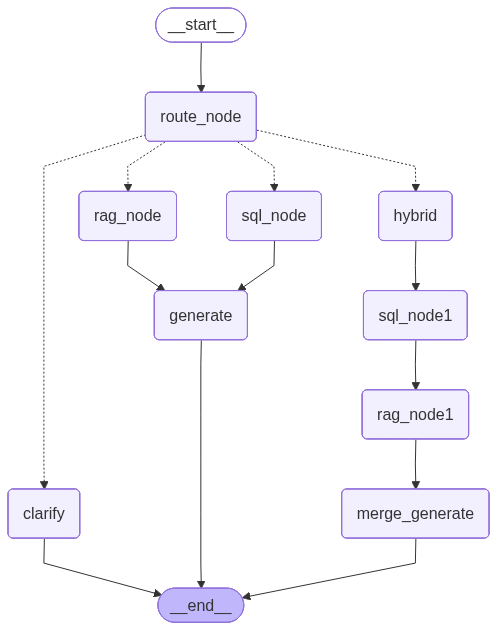

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
import gradio as gr
import uuid
from copy import deepcopy
from langchain_core.messages import HumanMessage

# def history_to_text(history, keep_last_n=8):
#     lines = []
#     for m in history[-keep_last_n:]:
#         role = m.get("role", "")
#         content = (m.get("content") or "").strip()
#         if not content:
#             continue

#         if role == "user":
#             lines.append(f"用户：{content}")
#         elif role == "assistant":
#             lines.append(f"助手：{content}")

#     return "\n".join(lines)
def _content_to_text(content):
    if isinstance(content, str):
        return content.strip()

    if isinstance(content, list):
        texts = []
        for item in content:
            if isinstance(item, str) and item.strip():
                texts.append(item.strip())
            elif isinstance(item, dict) and item.get("type") == "text":
                text = str(item.get("text", "")).strip()
                if text:
                    texts.append(text)
        return "\n".join(texts).strip()

    # 媒体 / 文件消息（例如 {"path": "..."}）不参与问题改写上下文
    return ""
def history_to_text(history, keep_last_n=8):
    lines = []
    for m in history[-keep_last_n:]:
        role = m.get("role", "")
        content = _content_to_text(m.get("content"))

        if not content:
            continue

        if role == "user":
            lines.append(f"用户：{content}")
        elif role == "assistant":
            lines.append(f"助手：{content}")

    return "\n".join(lines)


def rewrite_user_query(message, history):
    # history 里通常已经包含了当前这条 user message
    history_without_current = history
    if history and history[-1].get("role") == "user" and history[-1].get("content") == message:
        history_without_current = history[:-1]

    # 没有历史就直接返回
    if not history_without_current:
        return message

    conversation_text = history_to_text(history_without_current, keep_last_n=8)

    prompt = f"""
你是一个多轮对话问题改写器。

你的任务是：
结合历史对话，把“当前用户问题”改写成一个独立、完整、可直接执行的查询问题。

要求：
1. 保留历史上下文中的公司名、报告期、指标名、比较对象、时间范围等关键信息
2. 如果当前问题已经完整，原样返回
3. 如果当前问题是追问（例如“那同比呢”“为什么增长”“画图看看”），补全成完整问题
4. 如果上一轮助手在向用户做澄清，而用户这轮是在补信息，也要把补充信息合并成完整问题
5. 不要回答问题，不要解释，不要输出 JSON
6. 只输出“改写后的完整问题”这一句

历史对话：
{conversation_text}

当前用户问题：
{message}
    """.strip()

    try:
        resp = llm.invoke([{"role": "user", "content": prompt}])
        rewritten = resp.content.strip()
        return rewritten if rewritten else message
    except Exception as e:
        print(f"[rewrite_user_query fallback] {e}")
        return message

def backend_respond(message, history, thread_id):
    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    standalone_query = rewrite_user_query(message, history)
    print(f"[standalone_query] {standalone_query}")

    final_answer = None
    final_payload = None
    last_ai_message = None

    input_state = {
        "query": standalone_query,
        "messages": [HumanMessage(content=standalone_query)]
    }

    for chunk in graph.stream(
        input_state,
        config=config,
        stream_mode="values"
    ):
        if "final_answer" in chunk:
            final_answer = chunk["final_answer"]

        if "final_payload" in chunk:
            final_payload = chunk["final_payload"]

        msgs = chunk.get("messages", [])
        for msg in reversed(msgs):
            if isinstance(msg, AIMessage):
                last_ai_message = msg.content
                break
            if isinstance(msg, dict) and msg.get("role") == "assistant":
                last_ai_message = msg.get("content", "")
                break

    # 优先返回完整 payload
    if final_payload:
        return {
            "content": final_payload.get("content", "") or "",
            "image": final_payload.get("image", []) or []
        }

    # 兜底：没有 payload 时仍然兼容文本回答
    text = final_answer or last_ai_message or ""
    return {
        "content": text,
        "image": []
    }

def make_chat_id():
    return str(uuid.uuid4())[:8]

def make_default_sessions():
    chat_id = make_chat_id()
    return {
        chat_id: {
            "title": "新对话 1",
            "messages": [],
            "thread_id": chat_id,
        }
    }, chat_id

def session_choices(sessions):
    choices = []
    for chat_id, item in sessions.items():
        title = item["title"]
        choices.append((title, chat_id))
    return choices

def init_app():
    sessions, current_chat_id = make_default_sessions()
    current_messages = sessions[current_chat_id]["messages"]
    return (
        sessions,
        current_chat_id,
        gr.update(choices=session_choices(sessions), value=current_chat_id),
        current_messages,
        sessions[current_chat_id]["title"],
    )

def create_new_chat(sessions):
    sessions = deepcopy(sessions)
    new_id = make_chat_id()
    idx = len(sessions) + 1
    sessions[new_id] = {
        "title": f"新对话 {idx}",
        "messages": [],
        "thread_id": new_id,
    }
    return (
        sessions,
        new_id,
        gr.update(choices=session_choices(sessions), value=new_id),
        [],
        sessions[new_id]["title"]
    )

def switch_chat(selected_chat_id, sessions):
    if not selected_chat_id or selected_chat_id not in sessions:
        return [], ""
    return (
        sessions[selected_chat_id]["messages"],
        sessions[selected_chat_id]["title"]
    )

def send_message(user_message, sessions, current_chat_id):
    if not user_message.strip():
        yield (
            "",
            sessions,
            sessions[current_chat_id]["messages"],
            gr.update(choices=session_choices(sessions), value=current_chat_id),
            sessions[current_chat_id]["title"]
        )
        return

    sessions = deepcopy(sessions)
    current = sessions[current_chat_id]

    # 1) 用户消息
    current["messages"].append({
        "role": "user",
        "content": user_message
    })

    # 2) 首轮更新标题
    if current["title"].startswith("新对话") and len(current["messages"]) <= 1:
        current["title"] = user_message[:12]

    # 3) assistant 占位
    current["messages"].append({
        "role": "assistant",
        "content": "思考中..."
    })

    # 4) 先刷新一次
    yield (
        "",
        sessions,
        current["messages"],
        gr.update(choices=session_choices(sessions), value=current_chat_id),
        current["title"]
    )

    # 5) 调后端，拿到文本 + 图片
    payload = backend_respond(
        user_message,
        current["messages"][:-1],   # 去掉“思考中...”
        current["thread_id"]
    )

    reply_text = payload.get("content", "") or ""
    reply_images = payload.get("image", []) or []

    # 路径转绝对路径，避免 Gradio 找不到文件
    valid_images = []
    for p in reply_images:
        if p:
            abs_p = os.path.abspath(p)
            if os.path.exists(abs_p):
                valid_images.append(abs_p)

    # 6) 组装 assistant 消息
    # 同一条消息里同时放文字和图片
#     content_parts = []
#     if reply_text:
#         content_parts.append(reply_text)

#     for img_path in valid_images:
#         content_parts.append({"path": img_path})

#     if not content_parts:
#         final_content = "未获取到结果"
#     elif len(content_parts) == 1:
#         final_content = content_parts[0]
#     else:
#         final_content = content_parts

#     current["messages"][-1] = {
#         "role": "assistant",
#         "content": final_content
#     }
    assistant_msgs = []

    if reply_text.strip():
        assistant_msgs.append({
            "role": "assistant",
            "content": reply_text.strip()
        })

    for img_path in valid_images:
        assistant_msgs.append({
            "role": "assistant",
            "content": {"path": img_path}
            # 如果你想更显式一点，也可以改成：
            # "content": gr.Image(value=img_path)
        })

    if not assistant_msgs:
        assistant_msgs.append({
            "role": "assistant",
            "content": "未获取到结果"
        })

    # 用正式回复替换掉最后一条“思考中...”
    current["messages"] = current["messages"][:-1] + assistant_msgs

    # 7) 再刷新一次
    yield (
        "",
        sessions,
        current["messages"],
        gr.update(choices=session_choices(sessions), value=current_chat_id),
        current["title"]
    )

def rename_chat(new_title, sessions, current_chat_id):
    if not current_chat_id or current_chat_id not in sessions:
        return sessions, gr.update(), ""
    sessions = deepcopy(sessions)
    sessions[current_chat_id]["title"] = new_title.strip() or sessions[current_chat_id]["title"]
    return (
        sessions,
        gr.update(choices=session_choices(sessions), value=current_chat_id),
        sessions[current_chat_id]["title"]
    )

def delete_chat(sessions, current_chat_id):
    sessions = deepcopy(sessions)
    if current_chat_id in sessions:
        del sessions[current_chat_id]

    # 删光了就自动建一个
    if not sessions:
        sessions, new_chat_id = make_default_sessions()
        return (
            sessions,
            new_chat_id,
            gr.update(choices=session_choices(sessions), value=new_chat_id),
            sessions[new_chat_id]["messages"],
            sessions[new_chat_id]["title"]
        )

    # 否则切到第一个
    new_chat_id = next(iter(sessions.keys()))
    return (
        sessions,
        new_chat_id,
        gr.update(choices=session_choices(sessions), value=new_chat_id),
        sessions[new_chat_id]["messages"],
        sessions[new_chat_id]["title"]
    )


with gr.Blocks(title="财报问答助手") as demo:
    sessions_state = gr.State({})
    current_chat_id_state = gr.State("")

    with gr.Sidebar(open=True):
        gr.Markdown("## 会话")
        btn_new = gr.Button("➕ 新建聊天", variant="primary")

        chat_list = gr.Radio(
            choices=[],
            label="历史会话",
            value=None
        )

        rename_box = gr.Textbox(
            label="重命名当前会话",
            placeholder="输入新名称"
        )
        btn_rename = gr.Button("✏️ 重命名")

        btn_delete = gr.Button("🗑️ 删除当前会话", variant="stop")

    with gr.Column():
        current_title = gr.Markdown("### 当前会话")
        chatbot = gr.Chatbot(
            label="聊天窗口",
            height=600,
        )

        with gr.Row():
            user_input = gr.Textbox(
                placeholder="请输入你的问题…",
                scale=8
            )
            btn_send = gr.Button("发送", variant="primary", scale=1)

    # 页面初始化
    demo.load(
        fn=init_app,
        inputs=[],
        outputs=[
            sessions_state,
            current_chat_id_state,
            chat_list,
            chatbot,
            current_title
        ]
    )

    # 新建聊天
    btn_new.click(
        fn=create_new_chat,
        inputs=[sessions_state],
        outputs=[
            sessions_state,
            current_chat_id_state,
            chat_list,
            chatbot,
            current_title
        ]
    )

    # 切换会话
    chat_list.change(
        fn=lambda selected_id, sessions: (
            selected_id,
            *switch_chat(selected_id, sessions)
        ),
        inputs=[chat_list, sessions_state],
        outputs=[
            current_chat_id_state,
            chatbot,
            current_title
        ]
    )

    # 发送消息
    btn_send.click(
        fn=send_message,
        inputs=[user_input, sessions_state, current_chat_id_state],
        outputs=[
            user_input,
            sessions_state,
            chatbot,
            chat_list,
            current_title
        ]
    )

    user_input.submit(
        fn=send_message,
        inputs=[user_input, sessions_state, current_chat_id_state],
        outputs=[
            user_input,
            sessions_state,
            chatbot,
            chat_list,
            current_title
        ]
    )

    # 重命名
    btn_rename.click(
        fn=rename_chat,
        inputs=[rename_box, sessions_state, current_chat_id_state],
        outputs=[
            sessions_state,
            chat_list,
            rename_box,
            current_title
        ]
    )

    # 删除
    btn_delete.click(
        fn=delete_chat,
        inputs=[sessions_state, current_chat_id_state],
        outputs=[
            sessions_state,
            current_chat_id_state,
            chat_list,
            chatbot,
            current_title
        ]
    )

# demo.launch()
demo.queue().launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


[standalone_query] 华润三九近年来每股收益变化
---GENERATE ANSWER---


In [23]:
# 华润三九2023一季度每股收益是多少
import gradio as gr
print("gradio version =", gr.__version__)

gradio version = 6.9.0
